# Load and create dataset for HW2:Q2 data

remove particle positions as it is not needed in this task

In [232]:
import pickle as pkl
from torchvision.transforms import Compose, PILToTensor, Resize, ToTensor, Normalize
import numpy as np
import torch

# image_trans = Compose([Resize((28, 28)), ToTensor()])

data = pkl.load(open('hard_particle_dataset.pkl', 'rb'))


# image_trans = Compose([PILToTensor(), Resize((28, 28))])
# print(data.keys())

images = [img.astype(np.float32) for img in data["images"]]
images = list(map(ToTensor(), images))
# print(images[0])
# print(images[1])
images = list(map(lambda x: (x-x.min())/(x.max()-x.min()), images))     # Normalize the images to [0, 1]
# images = list(map(Normalize(mean=[0.5], std=[0.5]), images))            # Normalize to [-1, 1]
# print(images[0])
# images = list(map(Resize((28, 28)), images))

# images = list(map(image_trans(), data["images"]))

# labels = [torch.tensor(label[0]).float().unsqueeze(-1) for label in data["labels"]]
labels = [torch.tensor(label[0]).long() for label in data["labels"]]



# lab = torch.zeros((len(data["labels"]), len(np.unique([label[0] for label in data["labels"]]))))
# for i, l in enumerate(data["labels"]):
#     lab[i][int(l[0])] = 1
# labels = [label.float() for label in lab]



dataset = list(zip(images, labels))
# dataset = list(zip(list(map(ToTensor(), images)), list(map(lambda x: torch.tensor(x[0]).float().unsqueeze(-1), data["labels"]))))
# dataset = list(zip(data["images"], list(map(lambda x: x[0], data["labels"]))))
# dataset = [(img.reshape(64, 64), label) for img, label in dataset]

# print(dataset[0][0][0][0].dtype)
# print(len(dataset))
# print(dataset.shape)
# print(dataset[0].shape)
print(dataset[0][0].shape)
print(dataset[0][1].shape)
print(dataset[0][1])

# print(len(np.unique([label[0] for label in data["labels"]])))


torch.Size([1, 64, 64])
torch.Size([])
tensor(3)


### Override dataset with Mnist for testing


In [233]:
# import torchvision

# mnist_train = torchvision.datasets.MNIST(
#     root="data", 
#     train=True, 
#     download=False, 
#     transform=torchvision.transforms.ToTensor(),
# )
# mnist_test = torchvision.datasets.MNIST(
#     root="data", 
#     train=False, 
#     download=False, 
#     transform=torchvision.transforms.ToTensor(),
# )


# mnist_train, mnist_test = list(mnist_train), list(mnist_test)

# mnist_train = [(img, torch.tensor(label)) for img, label in mnist_train]
# mnist_test = [(img, torch.tensor(label)) for img, label in mnist_test]
# # print(len(mnist_train))
# # print(len(mnist_test))
# print(mnist_train[0][0].shape)
# print(mnist_train[0][1].shape)

# dataset = mnist_train
# dataset = [dataset[i] for i in range(len(dataset)) if dataset[i][1] < 6]

# print(dataset[0][0].shape)
# print(dataset[0][1].shape)
# print(dataset[0][1])

### Visualizing the Blood Smears

Implement a function to plot some examples of blood smears ...

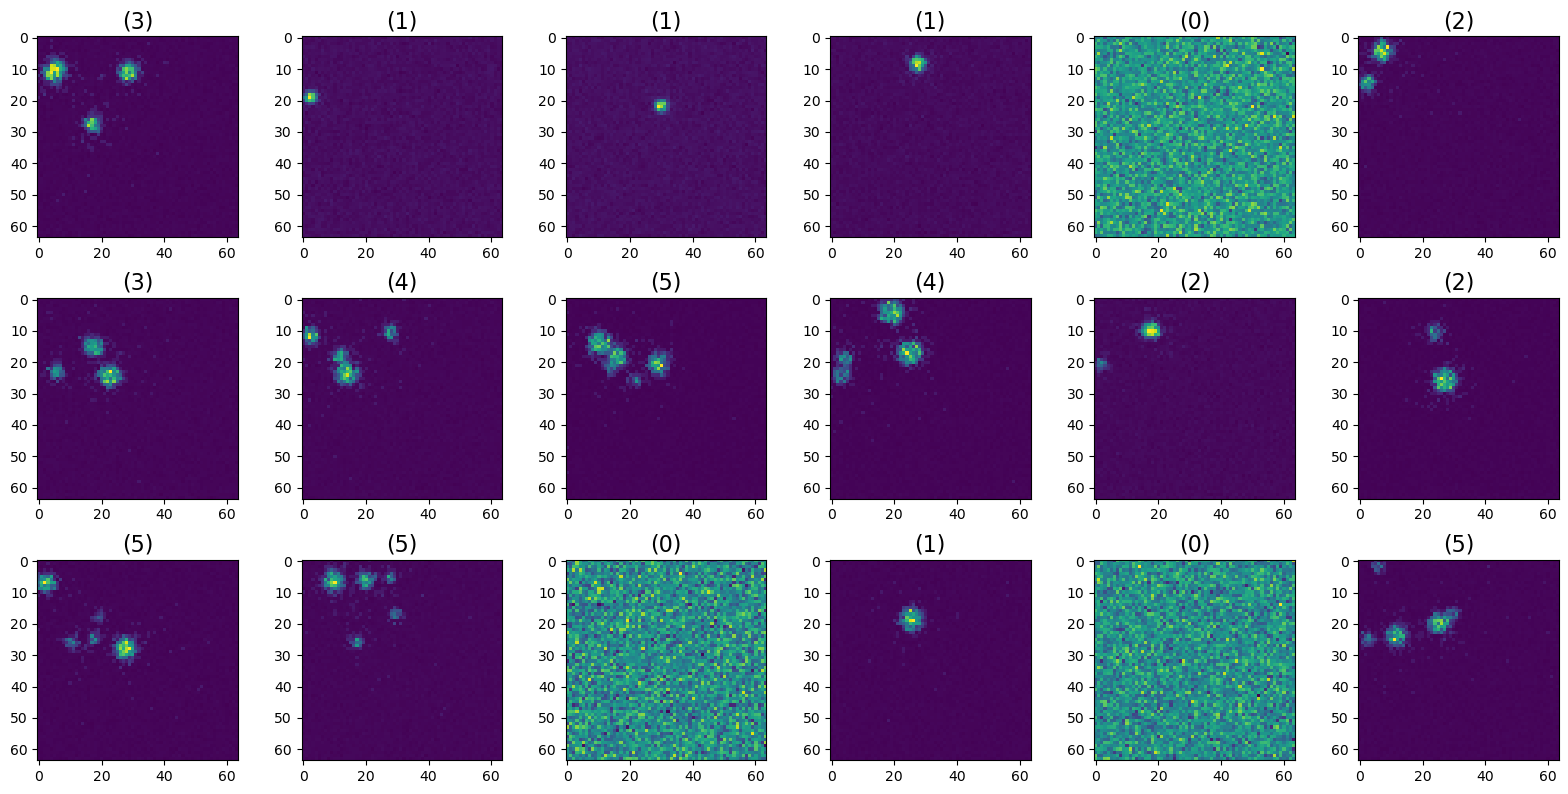

In [234]:
import matplotlib.pyplot as plt
import numpy as np

def plot_blood_smears(dataset, parasitized):
    """Plot blood smears."""
    fig, axs = plt.subplots(3, 6, figsize=(16, 8))
    for ax in axs.ravel():
        image, label = dataset[np.random.randint(0, len(dataset))]
        if isinstance(image, torch.Tensor):
            # image, label = image.numpy().transpose(1, 2, 0), np.where(label.numpy() == 1)[0][0]
            image, label = image.numpy().transpose(1, 2, 0), label.numpy()
        ax.imshow(image)
        ax.set_title(f"({label})" if label == parasitized
                     else f"({label})", fontsize=16)
    plt.tight_layout()
    plt.show()

plot_blood_smears(dataset, parasitized=1)

### Splitting the Dataset and Defining the Data Loaders



In [235]:
train, val, test = torch.utils.data.random_split(dataset, [0.7, 0.1, 0.2])

train_loader = torch.utils.data.DataLoader(train, batch_size=64, shuffle=True)
val_loader = torch.utils.data.DataLoader(val, batch_size=256, shuffle=False)
test_loader = torch.utils.data.DataLoader(test, batch_size=256, shuffle=False)

## Classifying the Blood Smears with Convolutional Neural Networks

Implement a convolutional neural network with a dense top ...

In [236]:
import deeplay as dl

conv_base = dl.ConvolutionalNeuralNetwork(
    in_channels=1, hidden_channels=[16, 16], out_channels=16,
)
conv_base.blocks[0].layer.configure(torch.nn.Conv2d, kernel_size=3, padding=1, stride=1)

# conv_base.blocks[0].normalization.configure(torch.nn.BatchNorm2d)
conv_base.blocks[0].pool.configure(torch.nn.MaxPool2d, kernel_size=2)

# conv_base.blocks[1].normalization.configure(torch.nn.BatchNorm2d)
conv_base.blocks[1].pool.configure(torch.nn.MaxPool2d, kernel_size=2)

# conv_base.blocks[2].normalization.configure(torch.nn.BatchNorm2d)
conv_base.blocks[2].pool.configure(torch.nn.MaxPool2d, kernel_size=2)


d = 0
conv_base.blocks[0].set_dropout(d)
conv_base.blocks[1].set_dropout(d)
conv_base.blocks[2].set_dropout(d)

# conv_base.blocks[3].normalization.configure(torch.nn.BatchNorm2d)
# conv_base.blocks[3].pool.configure(torch.nn.MaxPool2d, kernel_size=2)

# conv_base.blocks[4].normalization.configure(torch.nn.BatchNorm2d)
# conv_base.blocks[4].pool.configure(torch.nn.MaxPool2d, kernel_size=2)



connector = dl.Layer(torch.nn.AdaptiveAvgPool2d, output_size=1)

dense_top = dl.MultiLayerPerceptron(
    in_features=16, hidden_features=[32], out_features=6,
    out_activation=None
)
dense_top.blocks[0].set_dropout(d)
dense_top.blocks[1].set_dropout(d)
# dense_top.blocks[2].set_dropout(d)


cnn = dl.Sequential(conv_base, connector, dense_top)

# cnn_classifier = dl.CategoricalClassifier(
#     model=cnn, optimizer=dl.RMSprop(lr=0.001), num_classes=6
# ).create()
# cnn_classifier = dl.CategoricalClassifier(
#     model=cnn, optimizer=dl.SGD(lr=0.01), num_classes=6
# ).create()
cnn_classifier = dl.CategoricalClassifier(
    model=cnn, optimizer=dl.Adam(lr=0.001), num_classes=6
).create()
# cnn_classifier = dl.CategoricalClassifier(
#     model=dl.models.SmallMLP(in_features=64*64, out_features=6), optimizer=dl.Adam(lr=0.001), num_classes=6
# ).create()
# cnn_classifier = dl.CategoricalClassifier(
#     model=dl.models.SmallMLP(in_features=28*28, out_features=6), optimizer=dl.Adam(lr=0.001), num_classes=6
# ).create()

# cnn_classifier = dl.BinaryClassifier(
#     model=cnn, optimizer=dl.RMSprop(lr=0.001),
# ).create()
# cnn_classifier = dl.BinaryClassifier(
#     model=cnn, optimizer=dl.SGD(lr=0.001),
# ).create()

# print(cnn)
print(cnn_classifier)

CategoricalClassifier(
  (loss): CrossEntropyLoss()
  (train_metrics): MetricCollection(
    (MulticlassAccuracy): MulticlassAccuracy(),
    prefix=train
  )
  (val_metrics): MetricCollection(
    (MulticlassAccuracy): MulticlassAccuracy(),
    prefix=val
  )
  (test_metrics): MetricCollection(
    (MulticlassAccuracy): MulticlassAccuracy(),
    prefix=test
  )
  (model): Sequential(
    (0): ConvolutionalNeuralNetwork(
      (blocks): LayerList(
        (0): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
          (dropout): Dropout(p=0, inplace=False)
        )
        (1): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
          (dropout): 

### Training the Convolutional Neural Network

In [237]:
cnn_trainer = dl.Trainer(max_epochs=100, accelerator="auto")
cnn_trainer.fit(cnn_classifier, train_loader, val_loader)

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ CrossEntropyLoss │      0 │ train │     0 │
│ 1 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 4 │ model         │ Sequential       │  5.5 K │ train │     0 │
│ 5 │ optimizer     │ Adam             │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 5.5 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 5.5 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 37                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

c:\Users\jojac\anaconda3\envs\stoch\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\jojac\anaconda3\envs\stoch\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Users\jojac\anaconda3\envs\stoch\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 99: 100%|██████████| 132/132 [00:01<00:00, 131.52it/s, v_num=210, train_loss_step=0.353, trainMulticlassAccuracy_step=0.938, val_loss_step=0.470, valMulticlassAccuracy_step=0.784, val_loss_epoch=0.475, valMulticlassAccuracy_epoch=0.777, train_loss_epoch=0.465, trainMulticlassAccuracy_epoch=0.800]


(<Figure size 1500x500 with 2 Axes>,
 array([<Axes: title={'center': 'Loss'}, xlabel='Step'>,
        <Axes: title={'center': 'Multiclassaccuracy'}, xlabel='Step'>],
       dtype=object))

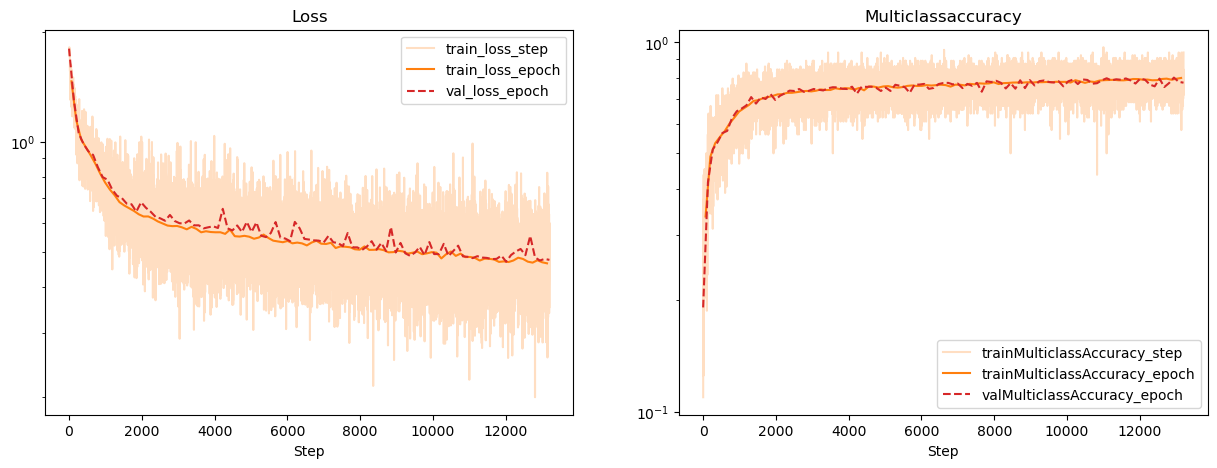

In [238]:
cnn_trainer.history.plot()

### Testing the Convolutional Neural Network

In [239]:
cnn_trainer.test(cnn_classifier, test_loader)

c:\Users\jojac\anaconda3\envs\stoch\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 10/10 [00:00<00:00, 89.18it/s] 


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃         Test metric          ┃         DataLoader 0         ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ testMulticlassAccuracy_epoch │      0.7708333134651184      │
│       test_loss_epoch        │     0.49930688738822937      │
└──────────────────────────────┴──────────────────────────────┘

[{'test_loss_epoch': 0.49930688738822937,
  'testMulticlassAccuracy_epoch': 0.7708333134651184}]

In [240]:
import torchmetrics as tm

f1 = tm.F1Score(task="multiclass", num_classes=6)
for image, label in test_loader:
    logits = cnn_classifier(image)
    preds = torch.argmax(logits, dim=1)
    # f1.update(preds, label.argmax(dim=-1))
    f1.update(preds, label)

print(f1.compute().item())

0.7708333134651184


### Plotting the ROC Curve

In [241]:
import torchmetrics as tm

def plot_roc(classifier, loader):
    """Plot ROC curve."""
    roc = tm.ROC(task="multiclass", num_classes=6)
    for image, label in loader:
        preds = classifier(image)
        # roc.update(preds, label.argmax(dim=-1).long())
        roc.update(preds, label)

    fig, ax = roc.plot(score=True)
    ax.grid(False)
    ax.axis("square")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc="center right")
    plt.show()

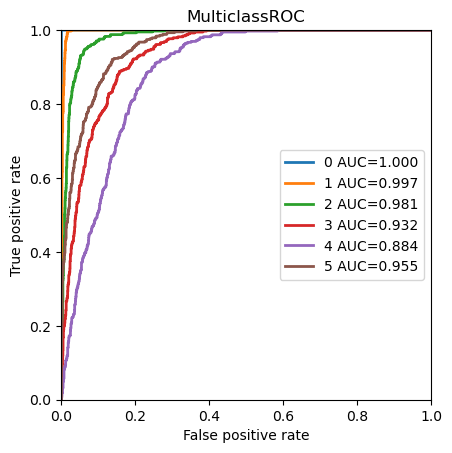

In [242]:
plot_roc(cnn_classifier, test_loader)
